In [17]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from scipy.sparse import vstack, load_npz
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as skm
import sklearn.utils as sku

import torch as pt
import torch.nn as nn
import torch.optim as optim

from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader

import optuna as opt

import Basic_functions as bf

from torchao.sparsity.training import (
    SemiSparseLinear,
    SemiSparseActivationLinear,
    swap_linear_with_semi_sparse_linear,
    swap_semi_sparse_linear_with_linear,
)

# Optional imports
# from torch.nn import L1Loss
# from scipy.special import expit

In [18]:
import numpy as np
from scipy import sparse
from scipy.sparse import load_npz
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import sklearn.utils as sku

# --------------------------------------------------------
# FILE IDS TO LOAD
# --------------------------------------------------------

file_ids = [
    "00",
    "01",
    "02",
    "03",
    "04",
    "05",
    "06",
    "07",
    "08",
    "09",
    "10",
    "11",
    "12",
    "13",
    "14",
    "15",
    "16",
    "17",
    "18"
]

# --------------------------------------------------------
# LOAD ARTICLE MATRICES
# --------------------------------------------------------

data_list = [
    load_npz(f"Data_files/data_articles_{fid}.npz")
    for fid in file_ids
]

# --------------------------------------------------------
# LOAD LABEL FILES
# --------------------------------------------------------

label_list = [
    np.genfromtxt(
        f"Data_files/labels_articles_{fid}.txt",
        delimiter="; ",
        dtype=str,
        encoding="latin1"
    )
    for fid in file_ids
]

# --------------------------------------------------------
# CREATE COMBINED DATASET
# --------------------------------------------------------

data_articles_all = sparse.vstack(data_list, format="csr")

labels_articles_all = np.vstack(label_list)

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

print("Initial data shape:", data_articles_all.shape)
print("Initial number of labels:", labels_articles_all.shape[0])

# --------------------------------------------------------
# LABEL COLUMN STRUCTURE
# --------------------------------------------------------
# index = 0 -> date
# index = 1 -> sermon or not
# index = 2 -> article title
# index = 3 -> article topic
# index = 4 -> lix score
# --------------------------------------------------------

# --------------------------------------------------------
# KEEP ONLY TOP X MOST FREQUENT TOPICS
# --------------------------------------------------------

top_x = 10

topics = labels_articles_all[:, 3]

unique_topics, topic_counts = np.unique(
    topics,
    return_counts=True
)

sorted_indices = np.argsort(topic_counts)[::-1]

valid_topics = unique_topics[
    sorted_indices[:top_x]
]

keep_mask = np.isin(
    topics,
    valid_topics
)

print("Original number of articles:", data_articles_all.shape[0])
print("Filtered number of articles:", keep_mask.sum())
print("Removed articles:", data_articles_all.shape[0] - keep_mask.sum())

print("\nTop topics kept:")
for topic in valid_topics:
    count = np.sum(topics == topic)
    print(f"{topic}: {count}")

# Apply top-10 filtering
data_articles_all = data_articles_all[keep_mask]
labels_articles_all = labels_articles_all[keep_mask]

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

# --------------------------------------------------------
# COMBINE / SHUFFLE DATA AFTER TOP-10 FILTERING
# --------------------------------------------------------

data_articles_all, labels_articles_all = sku.shuffle(
    data_articles_all,
    labels_articles_all,
    random_state=5466542
)

# --------------------------------------------------------
# ADD LIX SCORE AS FIRST COLUMN
# --------------------------------------------------------

lix_scores = labels_articles_all[:, 4].astype(np.float32)

assert data_articles_all.shape[0] == len(lix_scores)

lix_column = sparse.csr_matrix(
    lix_scores.reshape(-1, 1)
)

data_articles_all = sparse.hstack(
    [lix_column, data_articles_all],
    format="csr"
)

print("Shape after adding LIX:", data_articles_all.shape)

# --------------------------------------------------------
# APPLY COLUMN SORTING / FEATURE COMBING
# --------------------------------------------------------

sort_idx = np.genfromtxt(
    "txt_files/regression_sort_idx.txt",
    delimiter="\n",
    dtype=int
)

print("Data columns before sorting:", data_articles_all.shape[1])
print("Smallest sort index:", sort_idx.min())
print("Largest sort index:", sort_idx.max())

# Keep only indices that exist in the current feature matrix
sort_idx = sort_idx[
    sort_idx < data_articles_all.shape[1]
]

print("Number of valid sort indices:", len(sort_idx))

# Keep top 500 valid sorted features
data_articles_all = data_articles_all[:, sort_idx][:, :5000]

print("Shape after combing:", data_articles_all.shape)



# --------------------------------------------------------
# SCALE FEATURES
# --------------------------------------------------------

scaler = StandardScaler(with_mean=False)

data_articles_all = scaler.fit_transform(
    data_articles_all
)

# --------------------------------------------------------
# CONVERT TOPICS TO INTEGER LABELS
# --------------------------------------------------------

topic_labels = labels_articles_all[:, 3]

label_encoder = LabelEncoder()

topic_labels_encoded = label_encoder.fit_transform(
    topic_labels
)

# --------------------------------------------------------
# FINAL OUTPUT
# --------------------------------------------------------

print("\nFinal data shape:", data_articles_all.shape)
print("Final number of labels:", labels_articles_all.shape[0])

print("\nClasses:")
print(label_encoder.classes_)

print("\nExample feature row:")
print(data_articles_all[0])

print("\nExample label row:")
print(labels_articles_all[0])

Initial data shape: (853077, 27000)
Initial number of labels: 853077
Original number of articles: 853077
Filtered number of articles: 504327
Removed articles: 348750

Top topics kept:
Danmark: 150348
Internationalt: 144647
Sport: 42216
Kultur: 35301
Politik: 34656
Økonomi: 30938
Fodbold: 27503
Forbrug: 13721
Film og tv: 13120
Cykling: 11877
Shape after adding LIX: (504327, 27001)
Data columns before sorting: 27001
Smallest sort index: 0
Largest sort index: 27000
Number of valid sort indices: 27001
Shape after combing: (504327, 5000)

Final data shape: (504327, 5000)
Final number of labels: 504327

Classes:
['Cykling' 'Danmark' 'Film og tv' 'Fodbold' 'Forbrug' 'Internationalt'
 'Kultur' 'Politik' 'Sport' 'Økonomi']

Example feature row:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 147 stored elements and shape (1, 5000)>
  Coords	Values
  (0, 28)	7.266957653619334
  (0, 151)	3.203844547797791
  (0, 265)	6.64640962323575
  (0, 185)	1.6651791323057545
  (0, 48)	3.47954486

In [19]:
#class MyDataset(Dataset):    
    #def __init__(self, X_data, y_data):
        #self.input = X_data
        #self.truth = y_data
        
    #def __getitem__(self, index):
        #return self.input[index], self.truth[index]
        
    #def __len__ (self):
        #return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
#train_data = MyDataset(data_train, data_train_labels)
#val_data = MyDataset(data_val, data_val_labels)

import numpy as np
import pandas as pd
import torch as pt
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------------
# CREATE REGRESSION TARGET FROM ARTICLE DATE
# --------------------------------------------------------

y_years = labels_articles_all[:, 0].astype(np.float32)

valid_date_mask = ~np.isnan(y_years)

X_reg = data_articles_all[valid_date_mask]
y_years = y_years[valid_date_mask]

print("Earliest year:", y_years.min())
print("Latest year:", y_years.max())
print("Number of articles:", X_reg.shape[0])

y_scaler = StandardScaler()

y_scaled = y_scaler.fit_transform(
    y_years.reshape(-1, 1)
).astype(np.float32)

# --------------------------------------------------------
# SPLIT REGRESSION DATA INTO TRAIN, VAL, TEST SETS
# --------------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_reg,
    y_scaled,
    test_size=0.2,
    random_state=42
)


print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
#print("Test size:", X_test.shape[0])

class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data_reg = MyDataset(X_train, y_train)
val_data_reg = MyDataset(X_val, y_val)

Earliest year: 2000.1052
Latest year: 2026.4714
Number of articles: 504327
Train size: 403461
Validation size: 100866


In [20]:
# Training loop:
def Train(model, optimizer, loss_function, train_loader, validation_loader, device, epochs):
    validation_loss = []
    training_loss   = []
    model.train()
    for e in range(0, epochs):
        epoch_loss = 0
        n_minibatches = 0
        for input_train_batch, truth_train_batch in train_loader:
            input_train_batch, truth_train_batch = input_train_batch.to(device), truth_train_batch.to(device)
            optimizer.zero_grad()
            prediction = model(input_train_batch)  # This asks our model to produce predictions on the training batch            
            loss = loss_function(prediction, truth_train_batch.long())  # This calculates the loss
            loss.backward()                                             # This initiates the backpropagation
            optimizer.step()
            epoch_loss += loss.item()
            n_minibatches += 1
        
        # Now that the model have trained 1 epoch, we evaluate the model on the validation set:
        valid_loss = Validate(model, validation_loader, device, loss_function)
        validation_loss.append(valid_loss)
        training_loss.append(epoch_loss/n_minibatches)
        print('EPOCH: %s | training loss: %s  | validation loss: %s'%(e+1,round(epoch_loss/n_minibatches,3), round(valid_loss, 3)))
    return training_loss, validation_loss


def Validate(model, validation_loader, device, loss_function):
    model.eval()
    n_batches  = 0
    validation_loss = 0
    with pt.no_grad():
        for input_valid_batch, truth_valid_batch in validation_loader:
            input_valid_batch, truth_valid_batch = input_valid_batch.to(device), truth_valid_batch.to(device)
            prediction = model(input_valid_batch)
            loss = loss_function(prediction, truth_valid_batch.long())
            validation_loss += loss.item()
            n_batches += 1
    validation_loss = validation_loss/n_batches
    return validation_loss


def Predict(model, prediction_loader, device):
    model.eval()
    predictions = []
    print('PREDICTING!')
    with pt.no_grad():
        for input_pred_batch, _ in prediction_loader:
            input_pred_batch = input_pred_batch.to(device)
            prediction = model(input_pred_batch)
            predictions.extend(prediction.numpy())
    print('Done Predicting!')
    return predictions
                
class MeanRelativeAbsoluteDeviationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
                
    def forward(self, prediction, target):
        prediction = prediction.view_as(target)
        relative_absolute_error = pt.abs(prediction - target) / (pt.abs(target) + self.eps)
        return pt.mean(relative_absolute_error)

In [21]:
def sparse_collate(batch):
    xs, ys = zip(*batch)

    first = xs[0]
    n_features = first.shape[-1]

    batch_rows = []
    batch_cols = []
    batch_vals = []

    for i, x in enumerate(xs):
        x = x.tocoo()
        batch_rows.append(np.full_like(x.col, i, dtype=np.int64))
        batch_cols.append(x.col.astype(np.int64))
        batch_vals.append(x.data.astype(np.float32))

    indices = pt.tensor(
        np.vstack([np.concatenate(batch_rows), np.concatenate(batch_cols)]),
        dtype=pt.long
    )
    values = pt.tensor(np.concatenate(batch_vals), dtype=pt.float32)

    X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()
    y = pt.tensor(np.asarray(ys), dtype=pt.long)
    return X, y

In [ ]:
N_mult = 2
def objective(trial):

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-3,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [2,4,8,16,32,64,128]
    )

    Layer1 = trial.suggest_int("Layer1", 128*N_mult, 512*N_mult)
    Layer2 = trial.suggest_int("Layer2", 64*N_mult, 256*N_mult)
    Layer3 = trial.suggest_int("Layer3", 16*N_mult, 64*N_mult)

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.1,
        0.5
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-3,
        log=True
    )

    n_epochs = 5

    input_dim = X_train.shape[1]

    class OptRegressionModel(nn.Module):

        def __init__(self):
            super(OptRegressionModel, self).__init__()

            self.input_layer = nn.Linear(input_dim, Layer1)
            self.hidden_layer1 = nn.Linear(Layer1, Layer2)
            self.hidden_layer2 = nn.Linear(Layer2, Layer3)
            self.output_layer = nn.Linear(Layer3, 1)

            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(dropout_rate)

        def forward(self, inputs):

            x = self.input_layer(inputs)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer1(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer2(x)
            x = self.relu(x)

            x = self.output_layer(x)

            return x

    device = pt.device(
        "cuda" if pt.cuda.is_available() else "cpu"
    )

    model_opt = OptRegressionModel().to(device)

    loss_function = nn.MSELoss()

    optimizer = optim.Adam(
        model_opt.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    train_loader = DataLoader(
        dataset=train_data_reg,
        batch_size=batch_size,
        shuffle=True
    )

    validation_loader = DataLoader(
        dataset=val_data_reg,
        batch_size=batch_size,
        shuffle=False
    )

    best_validation_loss = float("inf")

    epoch_bar = tqdm(
        range(n_epochs),
        desc=f"Trial {trial.number}",
        leave=False,
        unit="epoch"
    )

    for epoch in epoch_bar:

        model_opt.train()
        epoch_training_loss = 0

        for input_batch, truth_batch in train_loader:

            input_batch = input_batch.to(device)
            truth_batch = truth_batch.to(device)

            optimizer.zero_grad()

            predictions = model_opt(input_batch).squeeze()

            loss = loss_function(
                predictions,
                truth_batch
            )

            loss.backward()
            optimizer.step()

            epoch_training_loss += loss.item()

        epoch_training_loss /= len(train_loader)

        model_opt.eval()
        epoch_validation_loss = 0

        with pt.no_grad():

            for input_batch, truth_batch in validation_loader:

                input_batch = input_batch.to(device)
                truth_batch = truth_batch.to(device)

                predictions = model_opt(input_batch).squeeze()

                loss = loss_function(
                    predictions,
                    truth_batch
                )

                epoch_validation_loss += loss.item()

        epoch_validation_loss /= len(validation_loader)

        best_validation_loss = min(
            best_validation_loss,
            epoch_validation_loss
        )

        epoch_bar.set_postfix(
            train_loss=f"{epoch_training_loss:.4f}",
            val_loss=f"{epoch_validation_loss:.4f}",
            best=f"{best_validation_loss:.4f}"
        )

        trial.report(epoch_validation_loss, epoch)

        if trial.should_prune():
            raise opt.exceptions.TrialPruned()

    return best_validation_loss

In [23]:
def progress_callback(study, trial):

    optuna_bar.update(1)

    if study.best_trial is not None:
        optuna_bar.set_postfix(
            best_loss=f"{study.best_value:.4f}",
            best_trial=study.best_trial.number
        )

# HP optimization

In [24]:
class SparseRegressionDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().squeeze()
        y = self.y[idx]

        return (
            pt.tensor(x, dtype=pt.float32),
            pt.tensor(y, dtype=pt.float32)
        )

train_data_reg = SparseRegressionDataset(X_train, y_train)
val_data_reg = SparseRegressionDataset(X_val, y_val)
#test_data_reg = SparseRegressionDataset(X_test, y_test)

In [25]:
from tqdm.auto import tqdm

n_trials = 50

pruner = opt.pruners.MedianPruner(
    n_startup_trials=2,
    n_warmup_steps=1
)

study = opt.create_study(
    direction="minimize",
    pruner=pruner
)

optuna_bar = tqdm(
    total=n_trials,
    desc="Optuna Trials",
    unit="trial"
)

device = pt.device(
    "cuda" if pt.cuda.is_available() else "cpu"
)

print(device)

study.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[progress_callback]
)

optuna_bar.close()

print("Best trial:")
print(study.best_trial)

print("Best parameters:")
print(study.best_trial.params)

best_params = study.best_trial.params

learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]
dropout_rate = best_params["dropout_rate"]
weight_decay = best_params["weight_decay"]

Layer1 = best_params["Layer1"]
Layer2 = best_params["Layer2"]
Layer3 = best_params["Layer3"]

[I 2026-06-06 17:24:45,332] A new study created in memory with name: no-name-b9cb226e-1e10-464d-9e00-d7b8d812c1a8


Optuna Trials:   0%|          | 0/50 [00:00<?, ?trial/s]

cpu


Trial 0:   0%|          | 0/5 [00:00<?, ?epoch/s]

/opt/anaconda3/envs/app-ml/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([16, 1])) that is different to the input size (torch.Size([16])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/anaconda3/envs/app-ml/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([5, 1])) that is different to the input size (torch.Size([5])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/anaconda3/envs/app-ml/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2])). This will likely lead to incorrect results due to broadcasting. Please ensure they ha

...

Trial 48:   0%|          | 0/5 [00:00<?, ?epoch/s]

[I 2026-06-07 10:22:31,462] Trial 48 pruned. 


Trial 49:   0%|          | 0/5 [00:00<?, ?epoch/s]

[I 2026-06-07 10:33:18,618] Trial 49 pruned. 


Best trial:
FrozenTrial(number=42, state=<TrialState.COMPLETE: 1>, values=[0.9940481103950791], datetime_start=datetime.datetime(2026, 6, 7, 8, 15, 3, 960511), datetime_complete=datetime.datetime(2026, 6, 7, 8, 40, 9, 729715), params={'learning_rate': 1.3198332476704938e-05, 'batch_size': 16, 'Layer1': 937, 'Layer2': 163, 'Layer3': 121, 'dropout_rate': 0.13002169716019144, 'weight_decay': 6.14736811540374e-06}, user_attrs={}, system_attrs={}, intermediate_values={0: 0.9946953014283781, 1: 0.9942729198961008, 2: 0.9941967375499686, 3: 0.9941100153820936, 4: 0.9940481103950791}, distributions={'learning_rate': FloatDistribution(high=0.001, log=True, low=1e-05, step=None), 'batch_size': CategoricalDistribution(choices=(16, 32, 64)), 'Layer1': IntDistribution(high=1024, log=False, low=256, step=1), 'Layer2': IntDistribution(high=512, log=False, low=128, step=1), 'Layer3': IntDistribution(high=128, log=False, low=32, step=1), 'dropout_rate': FloatDistribution(high=0.5, log=False, low=0.1, s

# Split data before training

In [26]:
#class MyDataset(Dataset):    
    #def __init__(self, X_data, y_data):
        #self.input = X_data
        #self.truth = y_data
        
    #def __getitem__(self, index):
        #return self.input[index], self.truth[index]
        
    #def __len__ (self):
        #return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
#train_data = MyDataset(data_train, data_train_labels)
#val_data = MyDataset(data_val, data_val_labels)

import numpy as np
import pandas as pd
import torch as pt
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------------
# CREATE REGRESSION TARGET FROM ARTICLE DATE
# --------------------------------------------------------

y_years = labels_articles_all[:, 0].astype(np.float32)

valid_date_mask = ~np.isnan(y_years)

X_reg = data_articles_all[valid_date_mask]
y_years = y_years[valid_date_mask]

print("Earliest year:", y_years.min())
print("Latest year:", y_years.max())
print("Number of articles:", X_reg.shape[0])

y_scaler = StandardScaler()

y_scaled = y_scaler.fit_transform(
    y_years.reshape(-1, 1)
).astype(np.float32)

# --------------------------------------------------------
# SPLIT REGRESSION DATA INTO TRAIN, VAL, TEST SETS
# --------------------------------------------------------

X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X_reg,
    y_scaled,
    test_size=0.1,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp,
    y_train_temp,
    test_size=0.20,
    random_state=42
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data_reg = MyDataset(X_train, y_train)
val_data_reg = MyDataset(X_val, y_val)

class SparseRegressionDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().squeeze()
        y = self.y[idx]

        return (
            pt.tensor(x, dtype=pt.float32),
            pt.tensor(y, dtype=pt.float32)
        )

train_data_reg = SparseRegressionDataset(X_train, y_train)
val_data_reg = SparseRegressionDataset(X_val, y_val)
test_data_reg = SparseRegressionDataset(X_test, y_test)

Earliest year: 2000.1052
Latest year: 2026.4714
Number of articles: 504327
Train size: 363115
Validation size: 90779
Test size: 50433


In [44]:
print(
    f"Best hyperparameters:\n"
    f"  Learning rate = {learning_rate}\n"
    f"  Weight decay  = {weight_decay}\n"
    f"  Batch size    = {batch_size}\n"
    f"  Layer 1       = {Layer1}\n"
    f"  Layer 2       = {Layer2}\n"
    f"  Layer 3       = {Layer3}\n"
    f"  Dropout rate  = {dropout_rate:.4f}"
)

Best hyperparameters:
  Learning rate = 1.3198332476704938e-05
  Weight decay  = 6.14736811540374e-06
  Batch size    = 16
  Layer 1       = 937
  Layer 2       = 163
  Layer 3       = 121
  Dropout rate  = 0.1300


# Training

In [27]:
import torch as pt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

input_dim = X_train.shape[1]

learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]
weight_decay = best_params["weight_decay"]

Layer1 = best_params["Layer1"]
Layer2 = best_params["Layer2"]
Layer3 = best_params["Layer3"]

# Lower dropout for regression
dropout_rate = min(best_params["dropout_rate"], 0.15)

class DateRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, Layer1),
            nn.BatchNorm1d(Layer1),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(Layer1, Layer2),
            nn.BatchNorm1d(Layer2),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(Layer2, Layer3),
            nn.GELU(),

            nn.Linear(Layer3, 1)
        )

    def forward(self, x):
        return self.network(x)

device = pt.device("cuda" if pt.cuda.is_available() else "cpu")
model = DateRegressionModel().to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

loss_function = nn.SmoothL1Loss(beta=0.5)

train_loader = DataLoader(train_data_reg, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(val_data_reg, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data_reg, batch_size=batch_size, shuffle=False)

n_epochs = 10
patience = 7

best_val_loss = np.inf
best_state = None
bad_epochs = 0

training_loss = []
validation_loss = []

for epoch in tqdm(range(n_epochs)):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device).view(-1, 1)

        optimizer.zero_grad()
        pred = model(xb)

        loss = loss_function(pred, yb)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with pt.no_grad():
        for xb, yb in validation_loader:
            xb = xb.to(device)
            yb = yb.to(device).view(-1, 1)

            pred = model(xb)
            loss = loss_function(pred, yb)

            val_loss += loss.item()

    val_loss /= len(validation_loader)

    training_loss.append(train_loss)
    validation_loss.append(val_loss)

    print(
        f"Epoch {epoch+1:03d} | "
        f"train loss {train_loss:.4f} | "
        f"val loss {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        print("Early stopping")
        break

model.load_state_dict(best_state)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 001 | train loss 0.2694 | val loss 0.1953
Epoch 002 | train loss 0.1882 | val loss 0.1713
Epoch 003 | train loss 0.1610 | val loss 0.1637
Epoch 004 | train loss 0.1431 | val loss 0.1551
Epoch 005 | train loss 0.1289 | val loss 0.1651
Epoch 006 | train loss 0.1174 | val loss 0.1717
Epoch 007 | train loss 0.1086 | val loss 0.1529
Epoch 008 | train loss 0.1009 | val loss 0.1527
Epoch 009 | train loss 0.0939 | val loss 0.1582
Epoch 010 | train loss 0.0887 | val loss 0.1461


<All keys matched successfully>

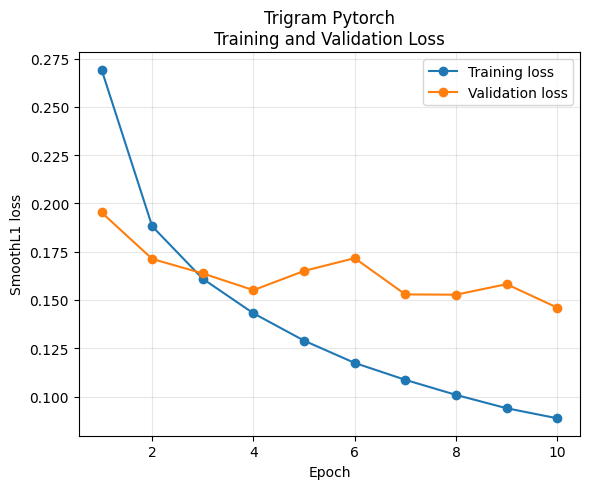

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, len(training_loss) + 1)

eps = 1e-12

log_train_final = np.log(training_loss[-1] + eps)
log_val_final = np.log(validation_loss[-1] + eps)
log_val_best = np.log(np.min(validation_loss) + eps)

plt.figure(figsize=(6, 5))

plt.plot(
    epochs,
    training_loss,
    marker="o",
    label="Training loss"
)

plt.plot(
    epochs,
    validation_loss,
    marker="o",
    label="Validation loss"
)



plt.xlabel("Epoch")
plt.ylabel("SmoothL1 loss")
plt.title("Trigram Pytorch Regression\nTraining and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Test

In [29]:
model.eval()
test_predictions_scaled = []

with pt.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        test_predictions_scaled.append(pred)

test_predictions_scaled = np.vstack(test_predictions_scaled)

true_test_years = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
predicted_test_years = y_scaler.inverse_transform(test_predictions_scaled).ravel()

mae = mean_absolute_error(true_test_years, predicted_test_years)
rmse = np.sqrt(mean_squared_error(true_test_years, predicted_test_years))
r2 = r2_score(true_test_years, predicted_test_years)

print(f"MAE  : {mae:.3f} years")
print(f"RMSE : {rmse:.3f} years")
print(f"R²   : {r2:.3f}")

MAE  : 2.026 years
RMSE : 2.784 years
R²   : 0.824


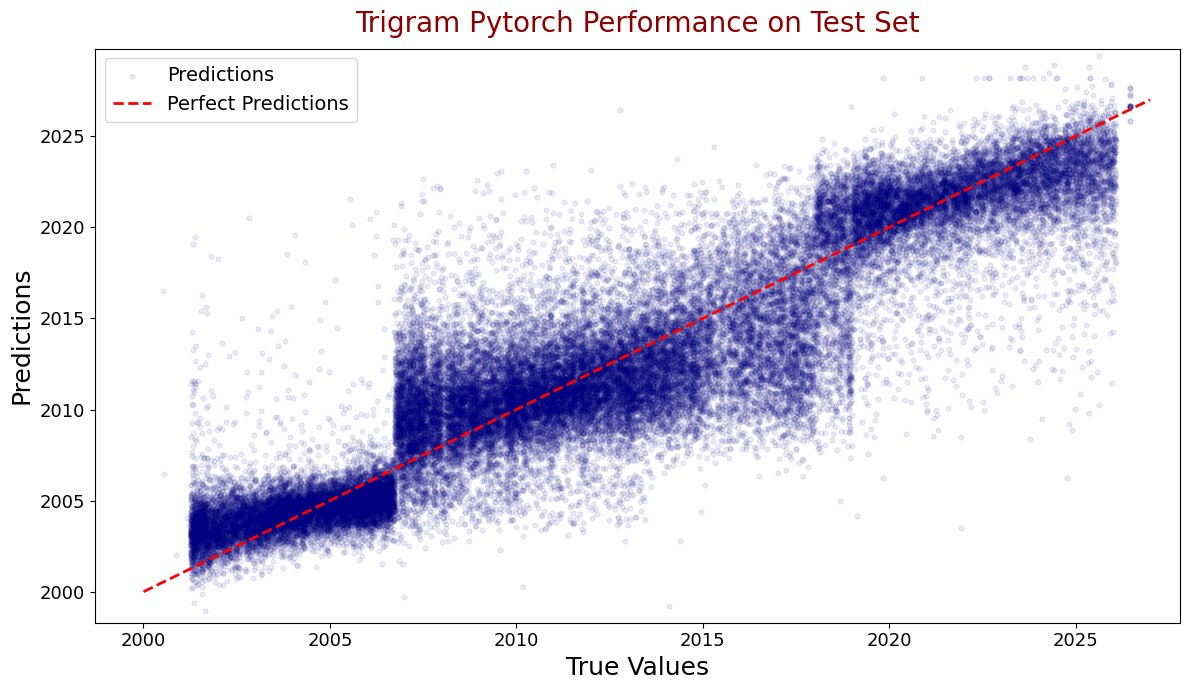

R²  = 0.824138
MSE = 7.749885


In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(true_test_years, predicted_test_years)
mse = mean_squared_error(true_test_years, predicted_test_years)

year_min = 2000
year_max = 2027

plt.figure(figsize=(12, 7))

plt.scatter(
    true_test_years,
    predicted_test_years,
    s=12,
    alpha=0.08,
    color="navy",
    label="Predictions"
)

plt.plot(
    [year_min, year_max],
    [year_min, year_max],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Predictions"
)

plt.xlim(1998.7, 2027.8)
plt.ylim(1998.3, 2029.8)

plt.xlabel("True Values", fontsize=18)
plt.ylabel("Predictions", fontsize=18)

plt.title(
    "Trigram Pytorch Performance on Test Set",
    fontsize=20,
    color="darkred",
    pad=12
)

plt.legend(fontsize=14, loc="upper left")
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.grid(False)
plt.tight_layout()

# Save figure before showing it
plt.savefig(
    "Regression_trigram_pytorch_test_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"R²  = {r2:.6f}")
print(f"MSE = {mse:.6f}")